In [48]:

import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


In [49]:

students_df = pd.read_csv("predict_students_dropout_and_academic_success.csv", sep = ";")
students_df.columns = students_df.columns.str.strip()


In [50]:

y = students_df["Target"]
students_df.drop("Target", axis = 1, errors = "ignore", inplace = True)


In [51]:

scaler = MinMaxScaler()
scaled_students_df = pd.DataFrame(scaler.fit_transform(students_df), columns = students_df.columns)
scaled_students_df.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,0.0,0.285714,0.555556,0.013858,1.0,0.0,0.284211,0.0,0.418605,0.255814,...,0.0,0.0,0.00000,0.000000,0.00,0.000000,0.0,0.372093,0.488889,0.766182
1,0.0,0.250000,0.111111,0.925989,1.0,0.0,0.684211,0.0,0.000000,0.046512,...,0.0,0.0,0.26087,0.181818,0.30,0.735897,0.0,0.732558,0.111111,0.640687
2,0.0,0.000000,0.555556,0.907512,1.0,0.0,0.284211,0.0,0.837209,0.837209,...,0.0,0.0,0.26087,0.000000,0.00,0.000000,0.0,0.372093,0.488889,0.766182
3,0.0,0.285714,0.222222,0.978108,1.0,0.0,0.284211,0.0,0.860465,0.837209,...,0.0,0.0,0.26087,0.303030,0.25,0.667692,0.0,0.209302,0.000000,0.124174
4,0.2,0.678571,0.111111,0.801466,0.0,0.0,0.052632,0.0,0.837209,0.860465,...,0.0,0.0,0.26087,0.181818,0.30,0.700000,0.0,0.732558,0.111111,0.640687


In [64]:

def plotar_kmeans(k):
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 'auto')
    clusters = kmeans.fit_predict(scaled_students_df)
    pca = PCA(n_components = 3)
    X_pca = pca.fit_transform(scaled_students_df)

    plt.figure(figsize = (10,8))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c = clusters, alpha = 0.6)
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.title(f"K-Means (k={k}) - Plano XY")
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize = (10,8))
    plt.scatter(X_pca[:, 0], X_pca[:, 2], c = clusters, alpha = 0.6)
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 3")
    plt.title(f"K-Means (k={k}) - Plano XZ")
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize = (10,8))
    plt.scatter(X_pca[:, 1], X_pca[:, 2], c = clusters, alpha = 0.6)
    plt.xlabel("Componente Principal 2")
    plt.ylabel("Componente Principal 3")
    plt.title(f"K-Means (k={k}) - Plano YZ")
    plt.grid(True)
    plt.show()

def plotar_kmeans_3d(k):
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 'auto')
    clusters = kmeans.fit_predict(scaled_students_df)
    pca = PCA(n_components = 3)
    X_pca = pca.fit_transform(scaled_students_df)
    df_pca = pd.DataFrame(X_pca, columns = ['PC1', 'PC2', 'PC3'])
    df_pca['cluster'] = clusters.astype(str)
    cores = {
    '0': 'purple',
    '1': 'yellow',
    '2': '#008B8B',
    '3': 'blue',
    '4': 'green',
    '5': 'red'
    }
    fig = px.scatter_3d(
        df_pca,
        x = 'PC1',
        y = 'PC2',
        z = 'PC3',
        color = 'cluster',
        opacity = 0.6,
        color_discrete_map = cores,
        title = (
            f'K-Means (k={k}) + PCA 3D '
            f'({pca.explained_variance_ratio_[0]*100:.2f}%, '
            f'{pca.explained_variance_ratio_[1]*100:.2f}%, '
            f'{pca.explained_variance_ratio_[2]*100:.2f}%)'
        )
    )
    fig.update_traces(marker = dict(size = 3))
    fig.update_layout(
        scene = dict(
            xaxis_title = f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
            yaxis_title = f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
            zaxis_title = f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)'
        )
    )
    
    fig.write_html(f"kmeans_3d_k={k}.html")
    print("Arquivo HTML criado!")
    fig.show()

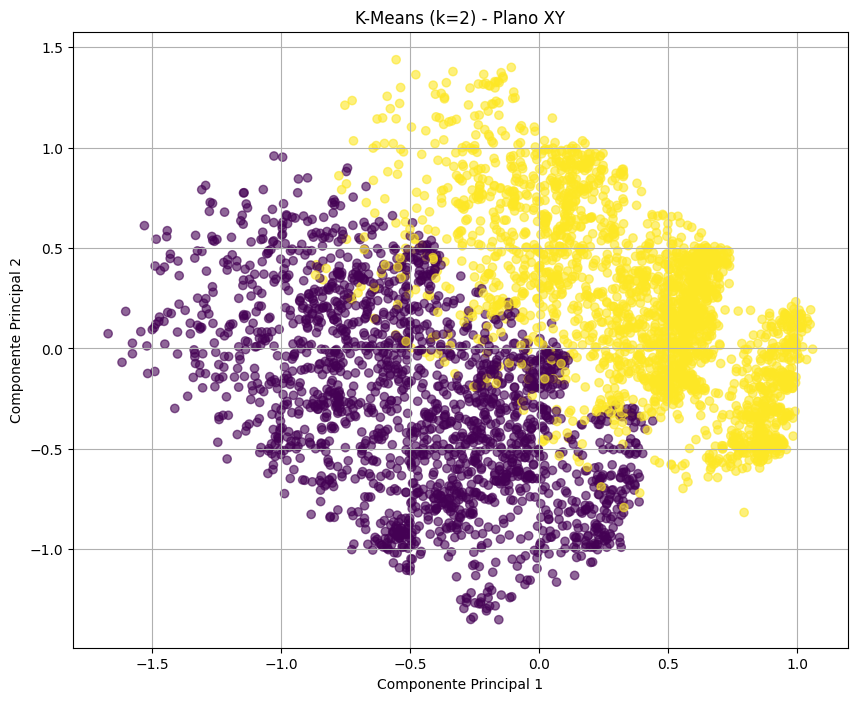

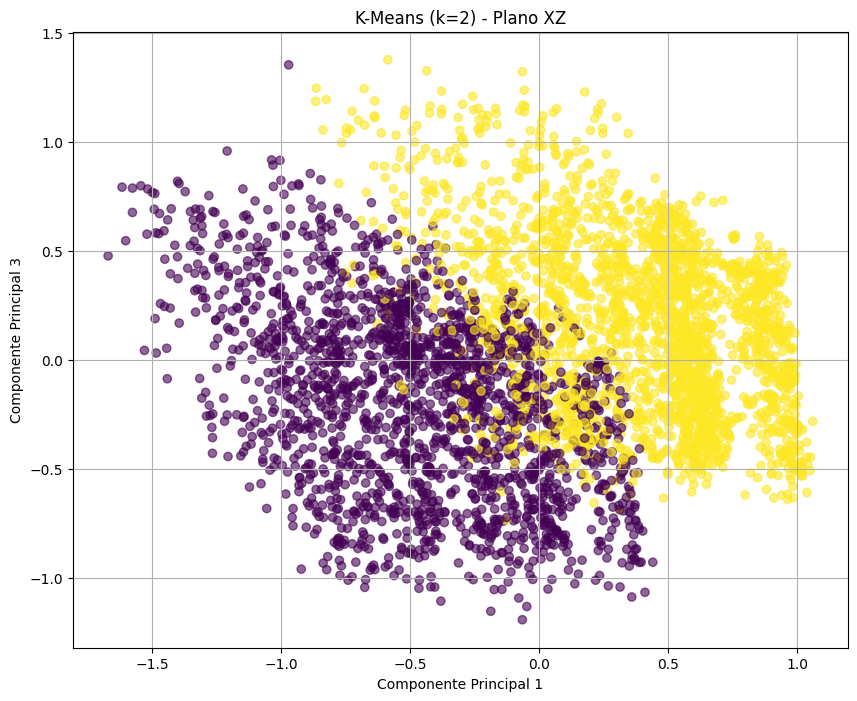

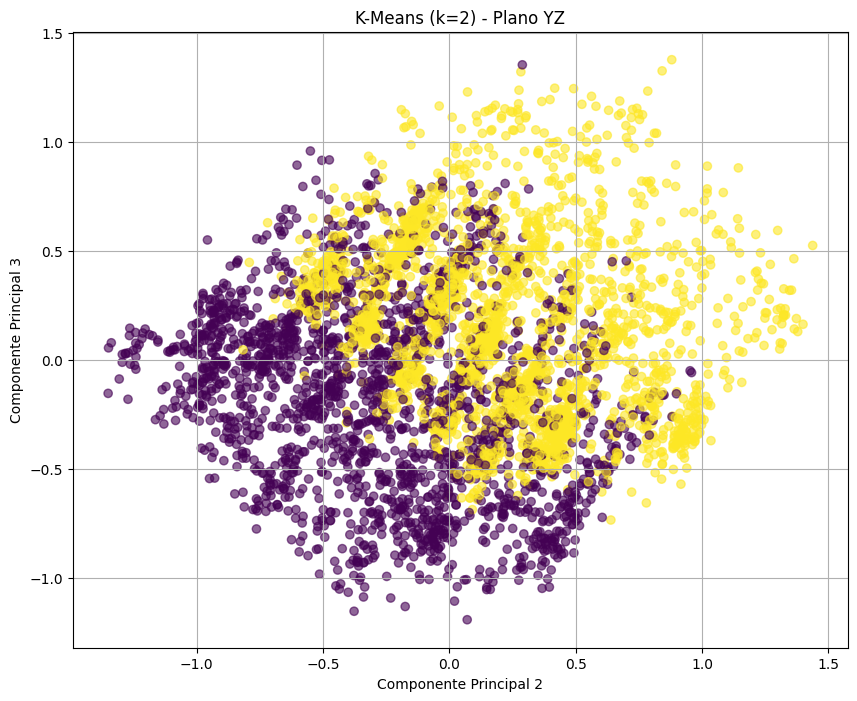

In [69]:

plotar_kmeans(k=2)
#plotar_kmeans_3d(k=3)
#plotar_kmeans_3d(k=4)
#plotar_kmeans_3d(k=5)
